In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/brendan45774/test-file/tested.csv


In [31]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("/kaggle/input/datasets/brendan45774/test-file/tested.csv",usecols=['Age','Fare','Survived'])

In [6]:
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [8]:
df.isnull().sum()

Survived     0
Age         86
Fare         1
dtype: int64

In [9]:
si=SimpleImputer()

In [17]:
df['Age']=si.fit_transform(df[['Age']])
df['Fare']=si.fit_transform(df[['Fare']])

In [18]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [19]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns='Survived'),
                                              df['Survived'],
                                              random_state=0,
                                              test_size=0.3)

In [20]:
X_train.head()

,Age,Fare
96,76.00000,78.8500
381,26.00000,7.8792
89,2.00000,23.0000
233,30.27259,7.8792
191,30.27259,26.0000


In [22]:
y_train.head()

96     1
381    0
89     0
233    0
191    0
Name: Survived, dtype: int64

/tmp/ipykernel_57/1634151261.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


Text(0.5, 1.0, 'Age QQ Plot')

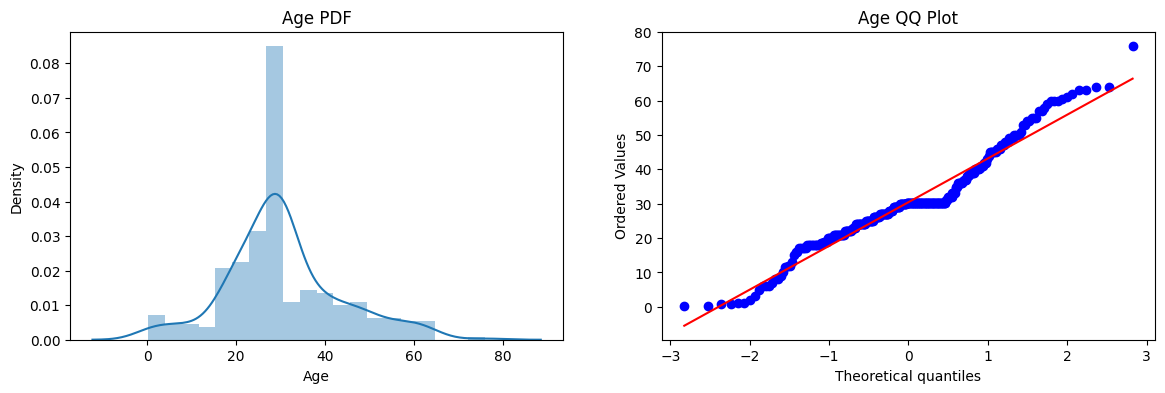

In [32]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'],dist="norm",plot=plt)
plt.title('Age QQ Plot')

/tmp/ipykernel_57/1905922649.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


Text(0.5, 1.0, 'Fare QQ Plot')

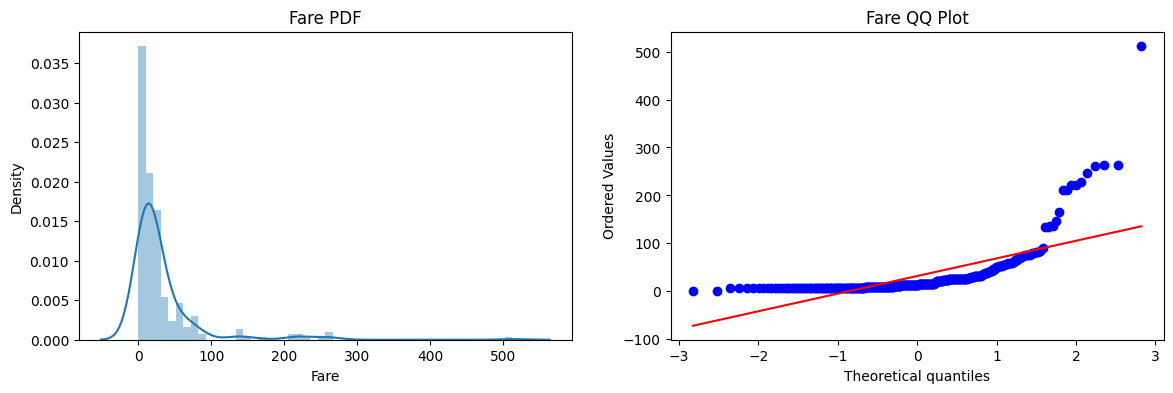

In [33]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'],dist="norm",plot=plt)
plt.title('Fare QQ Plot')

In [35]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

In [38]:
clf1.fit(X_train,y_train)

LogisticRegression()

In [39]:
clf2.fit(X_train,y_train)

DecisionTreeClassifier()

In [40]:
y_pred1=clf1.predict(X_test)
y_pred2=clf2.predict(X_test)

In [43]:
print("Accuracy\n")
print("Logistic regression:",accuracy_score(y_pred1,y_test))
print("Decision tree:",accuracy_score(y_pred2,y_test))

Accuracy

Logistic regression: 0.5634920634920635
Decision tree: 0.5158730158730159


In [45]:
trf=FunctionTransformer(func=np.log1p)

In [46]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.fit_transform(X_test)

In [47]:
clf1.fit(X_train_transformed,y_train)

LogisticRegression()

In [48]:
clf2.fit(X_train_transformed,y_train)

DecisionTreeClassifier()

In [49]:
y_pred1=clf1.predict(X_test_transformed)
y_pred2=clf2.predict(X_test_transformed)

In [50]:
print("Accuracy\n")
print("Logistic regression:",accuracy_score(y_pred1,y_test))
print("Decision tree:",accuracy_score(y_pred2,y_test))

Accuracy

Logistic regression: 0.5555555555555556
Decision tree: 0.5158730158730159


Text(0.5, 1.0, 'Transformed Age QQ Plot')

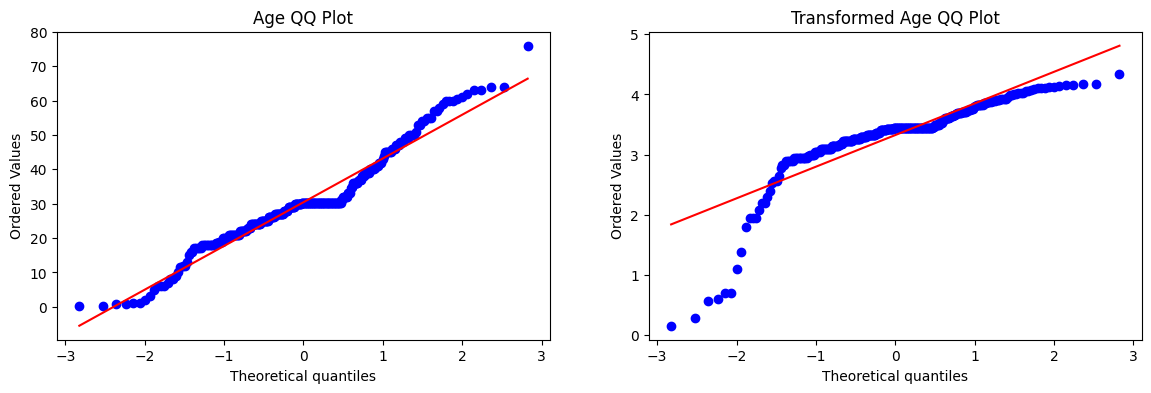

In [51]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'],dist="norm",plot=plt)
plt.title('Age QQ Plot')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'],dist="norm",plot=plt)
plt.title('Transformed Age QQ Plot')

Text(0.5, 1.0, 'Transformed Fare QQ Plot')

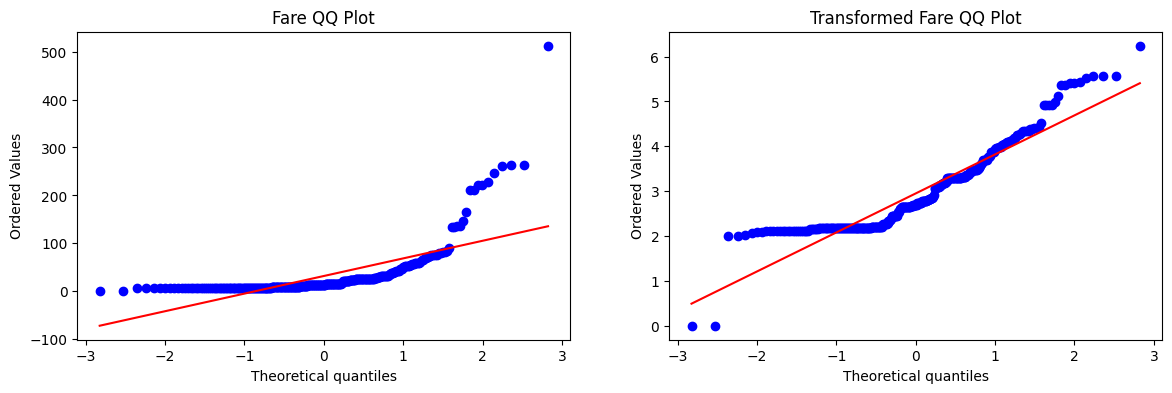

In [52]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'],dist="norm",plot=plt)
plt.title('Fare QQ Plot')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'],dist="norm",plot=plt)
plt.title('Transformed Fare QQ Plot')

In [55]:
trf1=ColumnTransformer([
    ('log',FunctionTransformer(func=np.log1p),['Fare'])
],remainder='passthrough')

In [56]:
X_train_transformed1=trf1.fit_transform(X_train)
X_test_transformed1=trf1.fit_transform(X_test)

In [57]:
clf1.fit(X_train_transformed1,y_train)

LogisticRegression()

In [58]:
clf2.fit(X_train_transformed1,y_train)

DecisionTreeClassifier()

In [59]:
y_pred1=clf1.predict(X_test_transformed1)
y_pred2=clf2.predict(X_test_transformed1)

In [60]:
print("Accuracy\n")
print("Logistic regression:",accuracy_score(y_pred1,y_test))
print("Decision tree:",accuracy_score(y_pred2,y_test))

Accuracy

Logistic regression: 0.5634920634920635
Decision tree: 0.49206349206349204
